#**DEEPP Milestone 2 – Data Cleaning & Exploratory Analysis**

## 1.Business Context & Analysis Objective


###**Business Context**

This project is part of the DEEPP (Data End-to-End Portfolio Project) for the RevoU Full Stack Data Analytics program. The dataset used is the Airline Passenger Satisfaction dataset, which captures passenger demographics, travel characteristics, service quality ratings, operational indicators, and overall satisfaction outcomes at the individual passenger level.

From a business perspective, the airline currently invests across multiple service and operational improvement initiatives but lacks clear, data driven prioritization of which factors most strongly influence passenger satisfaction. This limits effective resource allocation and reduces the impact of improvement efforts.

The primary stakeholder for this analysis is the Head of Customer Experience, who is responsible for deciding which service and operational areas should be prioritized to improve overall passenger satisfaction.

###**Analysis Objective for Milestone 2**

The objective of Milestone 2 is not to generate insights, rankings, or recommendations. This milestone focuses on assessing data readiness and data quality to determine whether the dataset is reliable and informative enough to support testing the predefined hypotheses in later milestones.

This includes evaluating whether the dataset structure aligns with the defined business problem and scope, identifying potential data quality issues that could bias analysis, and establishing a clean analytical foundation before deeper exploratory and comparative analysis is conducted.

By the end of this milestone, we aim to clearly understand whether the dataset can responsibly support future prioritization analysis and to document any limitations that must be considered in subsequent milestones.

## 2.Dataset Understanding

###2.1 Dataset Overview (Business Perspective)

The Airline Passenger Satisfaction dataset captures individual passenger experiences for airline travel. Each row is expected to represent a single passenger’s journey, along with their reported satisfaction outcome.

From a business standpoint, the dataset contains four broad categories of information:
- Passenger profile and demographics
- Travel and flight characteristics
- Service quality and experience ratings across multiple touchpoints
- Overall satisfaction outcome

This structure aligns with the business goal of understanding which service and operational areas are most strongly associated with passenger satisfaction and dissatisfaction, as it allows comparison across different aspects of the passenger experience within the same journey.

###2.2 Initial Data Structure Check
Before performing any data cleaning or transformation, an initial structural check is conducted to confirm:
- The number of observations and features in the dataset
- That each row represents an individual passenger record
- That the dataset is a single, flat table with no relational dependencies

At this stage, the purpose of the check is descriptive rather than corrective. No values are modified, removed, or imputed.


## 3.Analytical Setup & Data Hygiene

### 3.1 Library Imports

This analysis uses a minimal set of core Python libraries to support data inspection and validation. Libraries are imported only when necessary to avoid unused dependencies and to keep the analytical environment transparent and reproducible.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
raw_df = pd.read_csv("/content/drive/MyDrive/OCT25_FSDA_Amsterdam_[Dendy Satrio Wibowo]/DEEP/dataset/airline_passenger_satisfaction.csv")

raw_df.shape


(129880, 24)

In [ ]:
raw_df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied


### 3.2 Data Copying Strategy

To maintain analytical hygiene, the raw dataset is treated as read-only. All initial inspections and data quality assessments in this stage are performed on the raw dataset without any modification.

A working copy of the dataset will be created only when data cleaning decisions are explicitly applied in later sections. This approach ensures that raw data integrity is preserved and that any transformations are deliberate and traceable.

In [ ]:
df = raw_df.copy()

df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [ ]:
df.shape

(129880, 24)

At this point, a working copy of the dataset has been created. All subsequent data cleaning steps and exploratory analysis will be performed on this working copy (`df`), while the original dataset (`raw_df`) remains unchanged.


## 4.Data Quality Assessment



### 4.1 Missing Values Assessment

In [ ]:
df.isna().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,393
Departure and Arrival Time Convenience,0


In [ ]:
df['Arrival Delay'].isna().sum()


np.int64(393)

In [ ]:
df = df.dropna(subset=['Arrival Delay'])


In [ ]:
df['Arrival Delay'].isna().sum()


np.int64(0)

In [ ]:
df.shape


(129487, 24)

The dataset contains a minimal level of missing values, limited exclusively to the Arrival Delay variable. A total of 393 records (approximately 0.3% of all observations) were identified with missing arrival delay values, while all other variables were fully populated.

Since on-time arrivals are explicitly encoded in the dataset as zero delay, missing values in the Arrival Delay field do not represent no-delay scenarios and instead indicate incomplete or unrecorded delay information. To ensure a consistent and unambiguous definition of delay across the analysis, all records with missing Arrival Delay values were removed.

After this step, the dataset contains 129,487 observations and is considered fully suitable for subsequent exploratory analysis and visualization.

### 4.2 Duplicate Record Check


In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicate records were identified in the dataset. This supports the assumption that each row represents a unique passenger journey and indicates strong data integrity at the record level.


### 4.3 Data Type Validation


In [ ]:
df.dtypes

,0
ID,int64
Gender,object
Age,int64
Customer Type,object
Type of Travel,object
Class,object
Flight Distance,int64
Departure Delay,int64
Arrival Delay,float64
Departure and Arrival Time Convenience,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129487 non-null  int64  
 1   Gender                                  129487 non-null  object 
 2   Age                                     129487 non-null  int64  
 3   Customer Type                           129487 non-null  object 
 4   Type of Travel                          129487 non-null  object 
 5   Class                                   129487 non-null  object 
 6   Flight Distance                         129487 non-null  int64  
 7   Departure Delay                         129487 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129487 non-null  int64  
 10  Ease of Online Booking                  129487 no

In [ ]:
df["ID"] = df["ID"].astype(object)

df["Departure Delay"] = df["Departure Delay"].astype(float)

df.dtypes

,0
ID,object
Gender,object
Age,int64
Customer Type,object
Type of Travel,object
Class,object
Flight Distance,int64
Departure Delay,float64
Arrival Delay,float64
Departure and Arrival Time Convenience,int64


Two data type adjustments were applied to improve analytical clarity and consistency.

First, the `ID` column was converted from a numeric type to an object type to explicitly represent it as a unique identifier rather than a quantitative variable. This change ensures that the column is not unintentionally included in numerical summaries or calculations during exploratory analysis.

Second, the `Departure Delay` variable was converted from an integer type to a floating-point type to align with the `Arrival Delay` variable. This standardization ensures consistency across delay-related operational metrics and supports clearer interpretation in subsequent exploratory analysis.

These conversions do not alter any underlying values and are intended solely to improve data consistency and reduce analytical ambiguity.


### 4.4 Outlier Risk Review


In [ ]:
df[["Age", "Flight Distance", "Departure Delay", "Arrival Delay"]].describe()


,Age,Flight Distance,Departure Delay,Arrival Delay
count,129487.000000,129487.000000,129487.000000,129487.000000
mean,39.428761,1190.210662,14.643385,15.091129
std,15.117597,997.560954,37.932867,38.465650
min,7.000000,31.000000,0.000000,0.000000
25%,27.000000,414.000000,0.000000,0.000000
50%,40.000000,844.000000,0.000000,0.000000
75%,51.000000,1744.000000,12.000000,13.000000
max,85.000000,4983.000000,1592.000000,1584.000000


In [ ]:
df[["Age", "Flight Distance", "Departure Delay", "Arrival Delay"]].quantile([0.01, 0.99])


,Age,Flight Distance,Departure Delay,Arrival Delay
0.01,8.0,101.0,0.0,0.0
0.99,70.0,3884.0,180.0,182.0


In [ ]:
extreme_departure_delays = (df["Departure Delay"] >= 720).sum()
extreme_arrival_delays = (df["Arrival Delay"] >= 720).sum()

extreme_departure_delays, extreme_arrival_delays


(np.int64(19), np.int64(16))

In [ ]:
total_rows = df.shape[0]

extreme_departure_pct = round(extreme_departure_delays / total_rows * 100, 3)
extreme_arrival_pct = round(extreme_arrival_delays / total_rows * 100, 3)

extreme_departure_pct, extreme_arrival_pct


(np.float64(0.015), np.float64(0.012))

Although departure and arrival delay distributions contain extreme values, these values are statistically rare and operationally plausible. The 75th percentile of both delay variables remains low (12–13 minutes), indicating that the majority of passengers experience only minor delays.

Further inspection shows that delays exceeding 12 hours (720 minutes) affect less than 0.02% of observations. These extreme values are therefore treated as rare operational edge cases rather than data quality errors.

No outlier removal or adjustment was performed at this stage in order to preserve real-world operational variability.


## 5.Data Cleaning Decisions Summary

This section summarizes the data cleaning decisions made during Milestone 2, along with the rationale behind each decision.

First, the raw dataset was preserved as read only, and a working copy was created prior to any data inspection or transformation. This ensured that all cleaning actions were deliberate, traceable, and reversible.

A small amount of missing data was identified exclusively in the Arrival Delay variable, affecting 393 records (approximately 0.3% of total observations). Since on time arrivals are explicitly encoded in the dataset as zero delay, missing values in Arrival Delay do not represent no delay scenarios and instead indicate incomplete or unrecorded delay information. To ensure a consistent and unambiguous definition of delay, all records with missing Arrival Delay values were removed from the dataset.

No duplicate records were found, supporting the assumption that each row represents a unique passenger journey.

Data type validation indicated that most variables were already stored in appropriate formats. Two limited adjustments were applied: the ID column was explicitly treated as an identifier, and the Departure Delay variable was standardized to a floating point type to align with Arrival Delay. These changes improved analytical clarity without altering any underlying values.

Outlier assessment revealed the presence of extreme delay values. However, these cases were found to be extremely rare and operationally plausible rather than data quality errors. As such, no outlier removal or adjustment was performed in order to preserve real world operational variability.

Overall, the dataset is considered reliable and analysis ready for subsequent exploratory analysis and visualization, with all data quality considerations explicitly addressed and finalized prior to analysis.

In [ ]:
df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2.0,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26.0,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0.0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0.0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0.0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2.0,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0.0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6.0,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31.0,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied


## Segment Context Preparation (DEEP)



In [ ]:
df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2.0,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26.0,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0.0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0.0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0.0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2.0,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0.0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6.0,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31.0,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied


In [ ]:
# --- Age Band Derivation ---

age_bins = [0, 18, 30, 45, 60, 120]
age_labels = ['Teen', 'Young Adult', 'Adult', 'Older Adult', 'Senior']

df['Age_Band'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

# Quick validation
df[['Age', 'Age_Band']].head()


,Age,Age_Band
0,48,Older Adult
1,35,Adult
2,41,Adult
3,50,Older Adult
4,49,Older Adult


In [ ]:
df["Age_Band"].value_counts()

,count
Age_Band,
Adult,40953
Older Adult,38127
Young Adult,28428
Senior,12168
Teen,9811


In [ ]:
# --- Delay Severity Derivation ---

def delay_severity(delay):
    if delay <= 0:
        return 'On Time'
    elif delay <= 30:
        return 'Minor Delay'
    else:
        return 'Major Delay'

df['Delay_Severity'] = df['Arrival Delay'].apply(delay_severity)

# Quick validation
df[['Arrival Delay', 'Delay_Severity']].head()


,Arrival Delay,Delay_Severity
0,5.0,Minor Delay
1,39.0,Major Delay
2,0.0,On Time
3,0.0,On Time
4,1.0,Minor Delay


In [ ]:
df['Delay_Severity'].value_counts()


,count
Delay_Severity,
On Time,72753
Minor Delay,38359
Major Delay,18375


## 6.Exploratory Data Analysis (EDA) Framework

### 6.1 EDA Objectives

The purpose of exploratory data analysis (EDA) in Milestone 2 is to assess whether the dataset contains sufficient, reliable, and interpretable variation to support future analysis of passenger satisfaction drivers.

At this stage, EDA is used diagnostically rather than inferentially. The objective is not to determine which factors most strongly influence satisfaction, but to confirm that the data behaves in a way that makes such analysis feasible and meaningful in later milestones.

Specifically, the EDA in this milestone aims to:
- Validate that the satisfaction outcome variable is usable and reasonably distributed
- Confirm that service quality ratings exhibit meaningful variability across passengers
- Assess whether operational metrics reflect realistic airline operating conditions
- Ensure that key passenger and travel segments are large enough to support comparison in later analysis
- Identify early signals that indicate the dataset can support the predefined hypotheses without drawing conclusions


### 6.2 Why These Analyses (and Not Others)

The analyses selected for this EDA are intentionally limited in scope and depth. They focus on understanding data structure, distribution, and variability rather than quantifying relationships or testing hypotheses.

More advanced analyses such as correlation analysis, regression modeling, clustering, or hypothesis testing are intentionally excluded at this stage. These techniques require additional assumptions and could lead to premature conclusions that are not aligned with the objectives of Milestone 2.

By restricting EDA to diagnostic and readiness-focused analyses, this milestone ensures that subsequent prioritization and comparative analysis are grounded in a well-understood and reliable dataset, while maintaining clear separation between data assessment and business insight generation.

## 7.Key Explorations Conducted

### 7.1 Satisfaction Outcome Sanity Check

In [ ]:
df["Satisfaction"].value_counts()


,count
Satisfaction,
Neutral or Dissatisfied,73225
Satisfied,56262


In [ ]:
df["Satisfaction"].value_counts(normalize=True).round(3)


,proportion
Satisfaction,
Neutral or Dissatisfied,0.566
Satisfied,0.434


The satisfaction outcome variable shows a clear split between passengers who are satisfied and those who are neutral or dissatisfied.

Approximately 56.6% of passengers fall into the “Neutral or Dissatisfied” category, while 43.4% are classified as “Satisfied”. Both categories contain a large number of observations, indicating that the outcome variable is not overly imbalanced.

This distribution suggests that overall satisfaction provides sufficient variation to support comparative analysis in later stages. The presence of meaningful representation across both outcome groups confirms that satisfaction can be treated as a reliable analytical signal rather than a rare or trivial outcome.


### 7.2 Service Quality Rating Variability


In [ ]:
service_rating_cols = [
    "On-board Service",
    "Seat Comfort",
    "Cleanliness",
    "Food and Drink",
    "In-flight Service",
    "In-flight Wifi Service",
    "In-flight Entertainment",
    "Leg Room Service",
    "Check-in Service",
    "Online Boarding",
    "Gate Location"
]

df[service_rating_cols].describe()


,On-board Service,Seat Comfort,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Leg Room Service,Check-in Service,Online Boarding,Gate Location
count,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000
mean,3.383204,3.441589,3.286222,3.204685,3.642373,2.728544,3.358067,3.351078,3.306239,3.252720,2.976909
std,1.287032,1.319168,1.313624,1.329905,1.176614,1.329235,1.334149,1.316132,1.266146,1.350651,1.278506
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000
50%,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000,3.000000,3.000000,3.000000
75%,4.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Service quality rating variables exhibit meaningful variability across passengers. Across most service dimensions, ratings span from low to high values, with differences observed across lower, median, and upper quartiles.

This indicates that passenger evaluations of service quality are not uniform and provide sufficient variation to support comparative and prioritization analysis in subsequent stages.


### 7.3 Operational Metrics Distribution Review


In [ ]:
df[["Departure Delay", "Arrival Delay", "Flight Distance"]].describe()


,Departure Delay,Arrival Delay,Flight Distance
count,129487.000000,129487.000000,129487.000000
mean,14.643385,15.091129,1190.210662
std,37.932867,38.465650,997.560954
min,0.000000,0.000000,31.000000
25%,0.000000,0.000000,414.000000
50%,0.000000,0.000000,844.000000
75%,12.000000,13.000000,1744.000000
max,1592.000000,1584.000000,4983.000000


In [ ]:
df[["Departure Delay", "Arrival Delay", "Flight Distance"]].quantile([0.90, 0.95, 0.99])


,Departure Delay,Arrival Delay,Flight Distance
0.90,43.0,44.0,2752.0
0.95,77.0,78.0,3381.0
0.99,180.0,182.0,3884.0


In [ ]:
extreme_departure_delays = (df["Departure Delay"] > 720).sum()
extreme_arrival_delays = (df["Arrival Delay"] > 720).sum()

extreme_departure_delays, extreme_arrival_delays


(np.int64(19), np.int64(15))

In [ ]:
total_rows = df.shape[0]

round(extreme_departure_delays / total_rows * 100, 3), \
round(extreme_arrival_delays / total_rows * 100, 3)


(np.float64(0.015), np.float64(0.012))

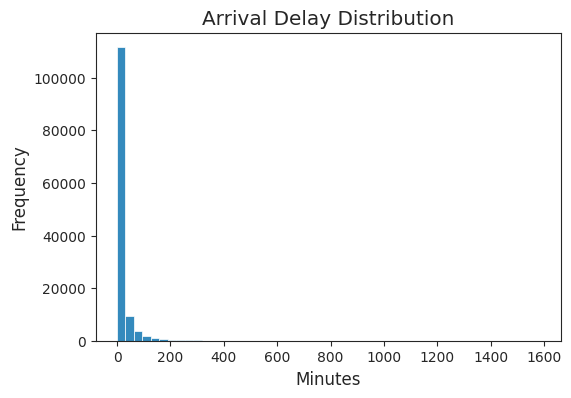

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(df["Arrival Delay"].dropna(), bins=50)
ax.set_title("Arrival Delay Distribution")
ax.set_xlabel("Minutes")
ax.set_ylabel("Frequency")
plt.show()


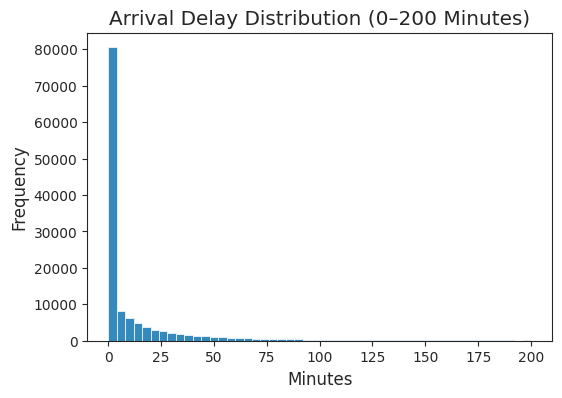

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(
    df["Arrival Delay"].dropna(),
    bins=50,
    range=(0, 200)
)

ax.set_title("Arrival Delay Distribution (0–200 Minutes)")
ax.set_xlabel("Minutes")
ax.set_ylabel("Frequency")

plt.show()


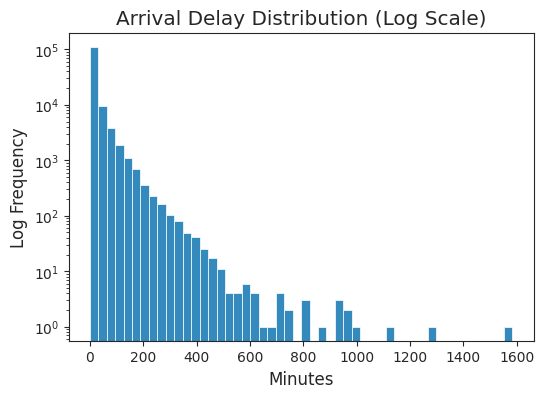

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(
    df["Arrival Delay"].dropna(),
    bins=50
)

ax.set_yscale("log")
ax.set_title("Arrival Delay Distribution (Log Scale)")
ax.set_xlabel("Minutes")
ax.set_ylabel("Log Frequency")

plt.show()


**Interpretation:**

The distribution of both departure and arrival delays is highly right-skewed.  
The majority of flights experience minimal delays, with the median delay at 0 minutes and the 75th percentile below 15 minutes for both metrics.

However, a small number of extreme delay values are observed, extending beyond 1,000 minutes. These cases represent less than 0.02% of total observations and likely reflect rare but legitimate operational disruptions (e.g., weather events, diversions, or cascading delays).

To balance interpretability and completeness, the analysis uses:
- A truncated histogram (0–200 minutes) to visualize typical passenger experience
- A log-scaled histogram to assess tail behavior and extreme delay risk

At this stage, extreme delays are retained without transformation, as the objective is to understand data characteristics rather than apply corrective modeling techniques.


### 7.4 Operational Reliability vs Passenger Satisfaction


#### 7.4.1 Arrival Delay Distribution by Satisfaction Group




This analysis examines how operational delays differ between passengers who are
*Satisfied* and those who are *Neutral or Dissatisfied*.

By comparing delay distributions across satisfaction groups, we aim to assess
whether operational reliability is meaningfully associated with negative
satisfaction outcomes, without making causal claims.

This serves as an early signal for whether delay-related metrics are likely to be
important drivers of dissatisfaction in later prioritization analysis.

In [ ]:
satisfied = df[df["Satisfaction"] == "Satisfied"]
not_satisfied = df[df["Satisfaction"] == "Neutral or Dissatisfied"]


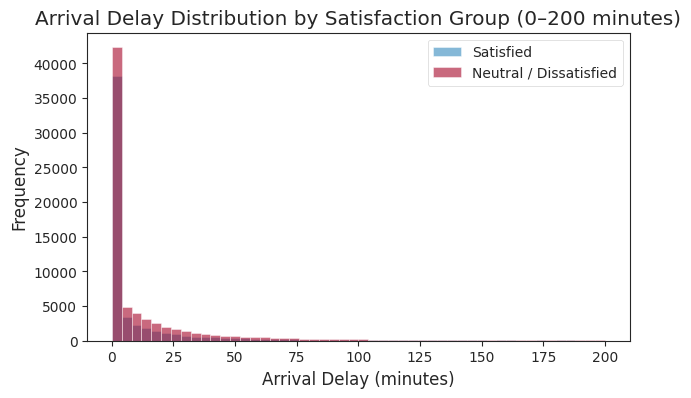

In [ ]:
# Plot arrival delay distributions (focus on 0–200 minutes for readability)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    satisfied["Arrival Delay"].dropna(),
    bins=50,
    range=(0, 200),
    alpha=0.6,
    label="Satisfied"
)

ax.hist(
    not_satisfied["Arrival Delay"].dropna(),
    bins=50,
    range=(0, 200),
    alpha=0.6,
    label="Neutral / Dissatisfied"
)

ax.set_title("Arrival Delay Distribution by Satisfaction Group (0–200 minutes)")
ax.set_xlabel("Arrival Delay (minutes)")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()


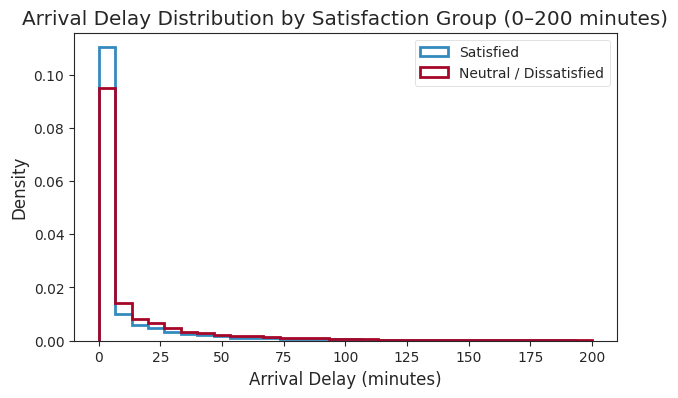

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    satisfied["Arrival Delay"].dropna(),
    bins=30,
    range=(0, 200),
    density=True,
    histtype="step",
    linewidth=2,
    label="Satisfied"
)

ax.hist(
    not_satisfied["Arrival Delay"].dropna(),
    bins=30,
    range=(0, 200),
    density=True,
    histtype="step",
    linewidth=2,
    label="Neutral / Dissatisfied"
)

ax.set_title("Arrival Delay Distribution by Satisfaction Group (0–200 minutes)")
ax.set_xlabel("Arrival Delay (minutes)")
ax.set_ylabel("Density")
ax.legend()

plt.show()


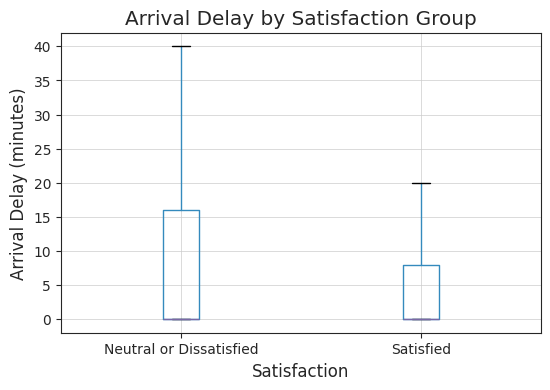

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

df.boxplot(
    column="Arrival Delay",
    by="Satisfaction",
    ax=ax,
    showfliers=False
)

ax.set_title("Arrival Delay by Satisfaction Group")
ax.set_xlabel("Satisfaction")
ax.set_ylabel("Arrival Delay (minutes)")
plt.suptitle("")  # remove default pandas title
plt.show()


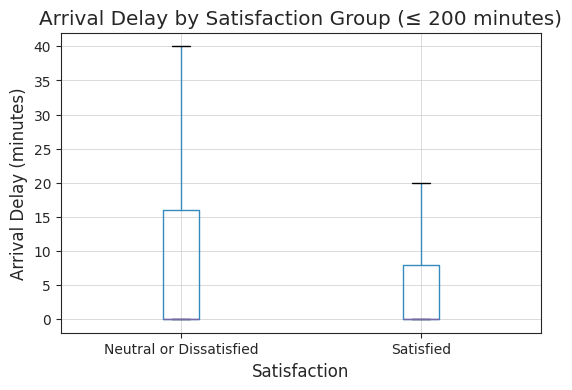

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

df[df["Arrival Delay"] <= 200].boxplot(
    column="Arrival Delay",
    by="Satisfaction",
    ax=ax,
    showfliers=False
)

ax.set_title("Arrival Delay by Satisfaction Group (≤ 200 minutes)")
ax.set_xlabel("Satisfaction")
ax.set_ylabel("Arrival Delay (minutes)")
plt.suptitle("")
plt.show()


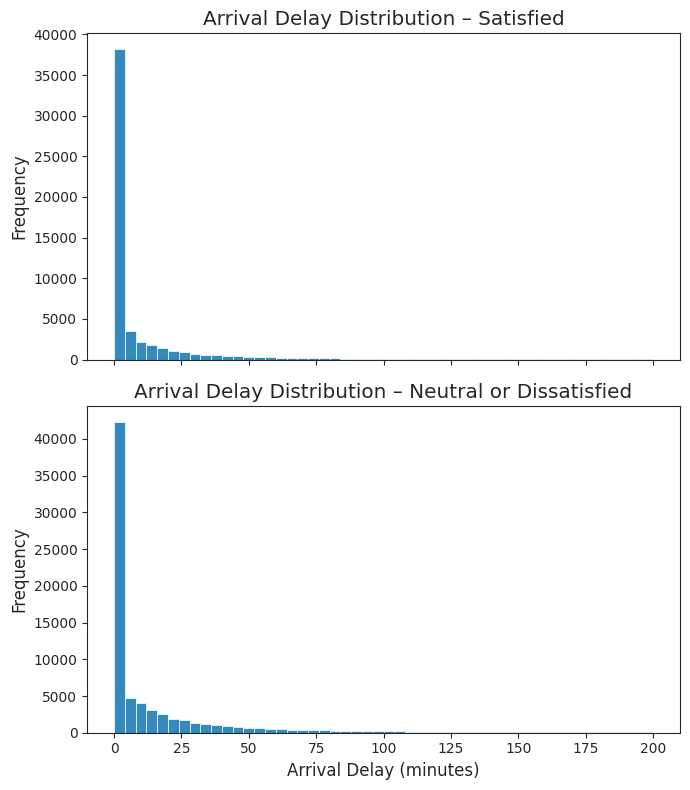

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

# Satisfied (Top)
axes[0].hist(
    df[df["Satisfaction"] == "Satisfied"]["Arrival Delay"].dropna(),
    bins=50,
    range=(0, 200)
)
axes[0].set_title("Arrival Delay Distribution – Satisfied")
axes[0].set_ylabel("Frequency")

# Neutral / Dissatisfied (Bottom)
axes[1].hist(
    df[df["Satisfaction"] == "Neutral or Dissatisfied"]["Arrival Delay"].dropna(),
    bins=50,
    range=(0, 200)
)
axes[1].set_title("Arrival Delay Distribution – Neutral or Dissatisfied")
axes[1].set_xlabel("Arrival Delay (minutes)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


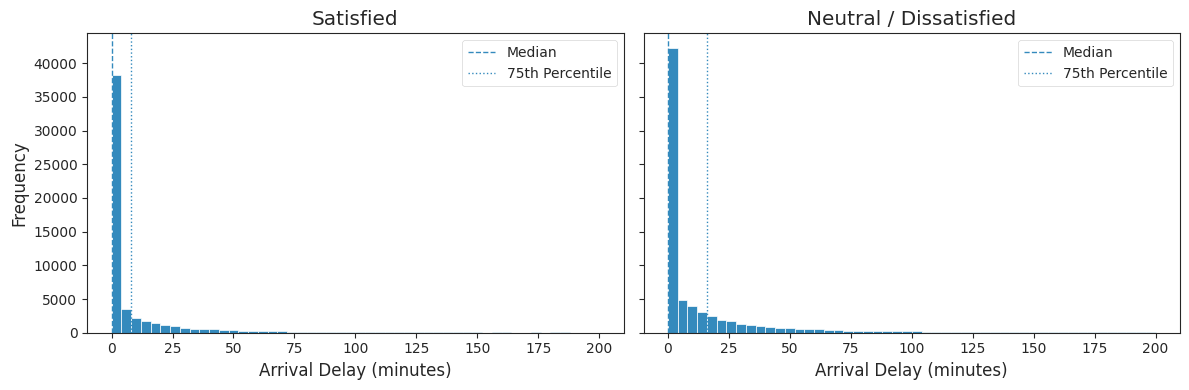

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# ---------- Satisfied (Left) ----------
satisfied_delay = df[df["Satisfaction"] == "Satisfied"]["Arrival Delay"].dropna()

axes[0].hist(
    satisfied_delay,
    bins=50,
    range=(0, 200)
)

# Garis referensi
axes[0].axvline(satisfied_delay.median(), linestyle="--", linewidth=1, label="Median")
axes[0].axvline(satisfied_delay.quantile(0.75), linestyle=":", linewidth=1, label="75th Percentile")

axes[0].set_title("Satisfied")
axes[0].set_xlabel("Arrival Delay (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].legend()


# ---------- Neutral / Dissatisfied (Right) ----------
not_satisfied_delay = df[df["Satisfaction"] == "Neutral or Dissatisfied"]["Arrival Delay"].dropna()

axes[1].hist(
    not_satisfied_delay,
    bins=50,
    range=(0, 200)
)

# Garis referensi
axes[1].axvline(not_satisfied_delay.median(), linestyle="--", linewidth=1, label="Median")
axes[1].axvline(not_satisfied_delay.quantile(0.75), linestyle=":", linewidth=1, label="75th Percentile")

axes[1].set_title("Neutral / Dissatisfied")
axes[1].set_xlabel("Arrival Delay (minutes)")
axes[1].legend()

plt.tight_layout()
plt.show()


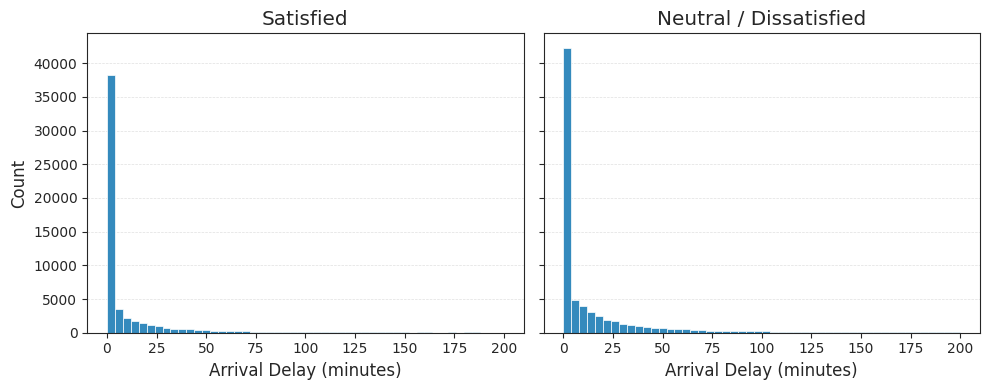

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

sat = df[df["Satisfaction"] == "Satisfied"]["Arrival Delay"].dropna()
not_sat = df[df["Satisfaction"] == "Neutral or Dissatisfied"]["Arrival Delay"].dropna()

axes[0].hist(sat, bins=50, range=(0, 200))
axes[0].set_title("Satisfied")
axes[0].set_xlabel("Arrival Delay (minutes)")
axes[0].set_ylabel("Count")

axes[1].hist(not_sat, bins=50, range=(0, 200))
axes[1].set_title("Neutral / Dissatisfied")
axes[1].set_xlabel("Arrival Delay (minutes)")

# === GRID YANG BENAR ===
for ax in axes:
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


Arrival Delay Distribution by Satisfaction Group

This visualization compares the distribution of arrival delays (0–200 minutes) between Satisfied and Neutral / Dissatisfied passengers.

Both groups show a strong right-skewed distribution, indicating that most flights arrive with minimal delay. However, the Neutral / Dissatisfied group exhibits higher frequencies in the 10–50 minute delay range, suggesting that moderate delays occur more often among passengers with lower satisfaction.

While extreme delays exist in both groups, they are relatively rare. Overall, the Satisfied group shows a more concentrated distribution near zero delay, indicating better perceived arrival reliability, whereas the Neutral / Dissatisfied group displays greater variability in arrival delays.

####7.4.2 Departure Delay Distribution by Satisfaction Group



This section examines the distribution of Departure Delay across satisfaction groups to assess whether service dissatisfaction is already observable at the early operational stage of the flight experience.

Similar to arrival delays, departure delays exhibit a strong right-skewed distribution, with the majority of flights departing on time or with only minimal delays. However, a long tail of delayed departures remains present in both satisfaction groups, indicating occasional but substantial operational disruptions.

When comparing groups, passengers in the Neutral or Dissatisfied category show a wider spread of departure delays and higher concentration of longer delays than those in the Satisfied group. In contrast, the satisfied group is more tightly clustered around low delay values, suggesting more consistent departure performance.

This pattern suggests that dissatisfaction is not solely driven by events occurring late in the journey, but may already originate from departure-stage operational issues such as scheduling inefficiencies, gate congestion, or ground handling delays. As a result, departure reliability appears to play an important role in shaping overall passenger satisfaction.

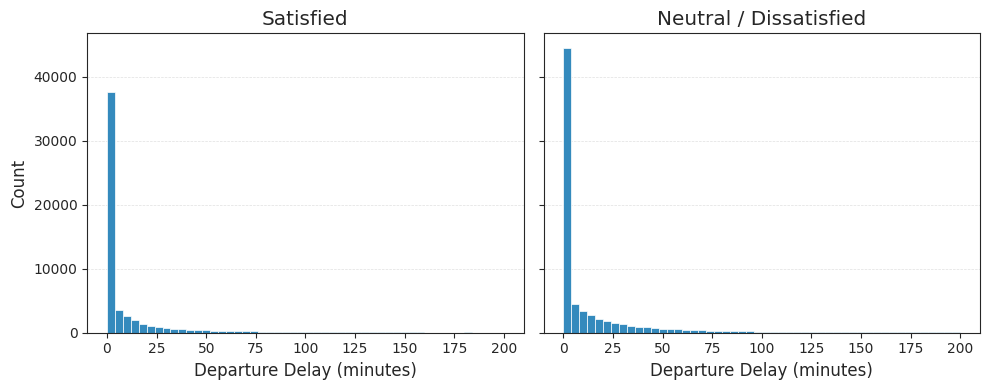

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Data
sat_dep = df[df["Satisfaction"] == "Satisfied"]["Departure Delay"].dropna()
not_sat_dep = df[df["Satisfaction"] == "Neutral or Dissatisfied"]["Departure Delay"].dropna()

# Satisfied
axes[0].hist(sat_dep, bins=50, range=(0, 200))
axes[0].set_title("Satisfied")
axes[0].set_xlabel("Departure Delay (minutes)")
axes[0].set_ylabel("Count")

# Neutral / Dissatisfied
axes[1].hist(not_sat_dep, bins=50, range=(0, 200))
axes[1].set_title("Neutral / Dissatisfied")
axes[1].set_xlabel("Departure Delay (minutes)")

# Grid (biar kebaca)
for ax in axes:
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


#### 7.4.3 Summary: Operational Delay Patterns and Satisfaction


This subsection summarizes the observed patterns from arrival and departure delay analyses to assess the overall role of operational reliability in passenger satisfaction.

Across both arrival and departure stages, delay distributions are heavily right-skewed, with most flights experiencing minimal delays. However, in both cases, passengers who report being Neutral or Dissatisfied are more frequently exposed to moderate and longer delays, while Satisfied passengers are more tightly concentrated around low delay values.

The consistency of this pattern across departure and arrival stages suggests that operational reliability issues are not isolated to a single point in the journey. Instead, delays appear to accumulate across the flight experience, reinforcing dissatisfaction as delays become more frequent or severe.

These findings indicate that operational delay metrics represent a meaningful analytical signal for understanding passenger dissatisfaction and justify their inclusion in subsequent prioritization and comparative analysis.


### 7.5 Satisfaction vs Service Execution



This subsection examines service execution quality across key human-led and process-driven touchpoints during the passenger journey. The analysis focuses on how service execution ratings differ between passengers who reported being satisfied and those who were neutral or dissatisfied.

All visualizations in this subsection are exploratory and distribution-based. Boxplots are used to assess central tendency and variability across service execution dimensions within each satisfaction group.


In [ ]:
satisfaction_col = 'Satisfaction'

service_execution_cols = [
    'Check-in Service',
    'On-board Service',
    'In-flight Service'
]


In [ ]:
df[[satisfaction_col] + service_execution_cols].head()


,Satisfaction,Check-in Service,On-board Service,In-flight Service
0,Neutral or Dissatisfied,4,3,5
1,Satisfied,3,5,5
2,Satisfied,4,3,3
3,Satisfied,3,5,5
4,Satisfied,3,3,3


In [ ]:
service_exec_melted = df.melt(
    id_vars=satisfaction_col,
    value_vars=service_execution_cols,
    var_name='Service Execution Dimension',
    value_name='Rating'
)

service_exec_melted


,Satisfaction,Service Execution Dimension,Rating
0,Neutral or Dissatisfied,Check-in Service,4
1,Satisfied,Check-in Service,3
2,Satisfied,Check-in Service,4
3,Satisfied,Check-in Service,3
4,Satisfied,Check-in Service,3
...,...,...,...
388456,Neutral or Dissatisfied,In-flight Service,5
388457,Neutral or Dissatisfied,In-flight Service,4
388458,Neutral or Dissatisfied,In-flight Service,4
388459,Satisfied,In-flight Service,4


####7.5.1 Service Execution Ratings – Satisfied Passengers
This visualization presents the distribution of service execution ratings among passengers who reported being satisfied. The chart summarizes perceived performance across core service execution dimensions, highlighting how ratings are distributed within this group.


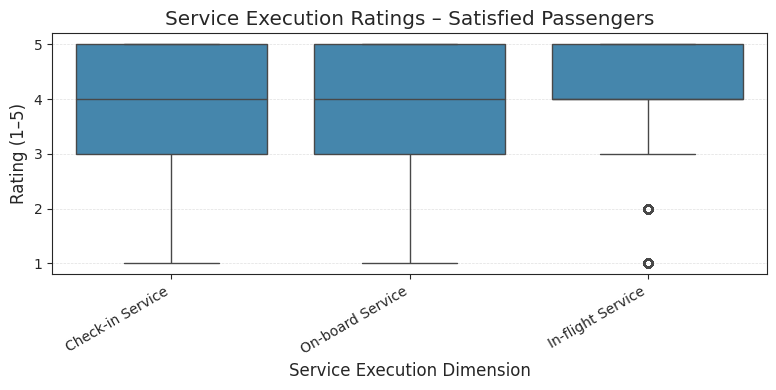

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=service_exec_melted[
        service_exec_melted[satisfaction_col] == 'Satisfied'
    ],
    x='Service Execution Dimension',
    y='Rating'
)

plt.title('Service Execution Ratings – Satisfied Passengers')
plt.xlabel('Service Execution Dimension')
plt.ylabel('Rating (1–5)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Among passengers who reported being satisfied, service execution ratings are generally concentrated at the higher end of the scale across all service dimensions. Median ratings for check-in service, on-board service, and in-flight service are relatively high, with narrower interquartile ranges, indicating more consistent service experiences within this group.

While some variability remains, the overall distribution suggests that satisfied passengers tend to experience stable and positively perceived service execution throughout the passenger journey.


####7.5.2 Service Execution Ratings – Neutral / Dissatisfied Passengers

This visualization presents the distribution of service execution ratings among passengers who reported being neutral or dissatisfied. The chart highlights differences in central tendency and variability across service execution dimensions within this group.


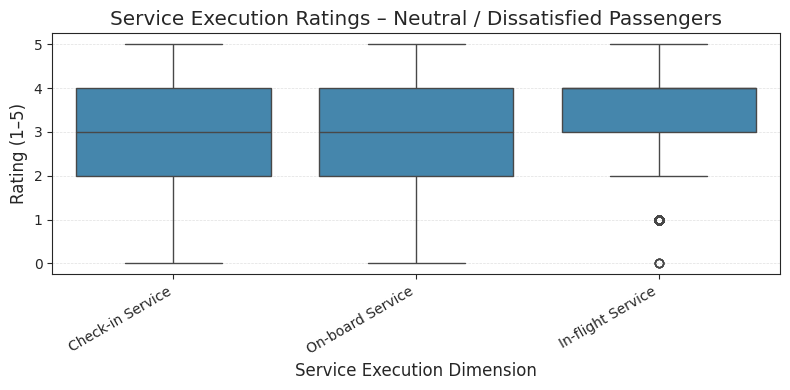

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=service_exec_melted[
        service_exec_melted[satisfaction_col] == 'Neutral or Dissatisfied'
    ],
    x='Service Execution Dimension',
    y='Rating'
)

plt.title('Service Execution Ratings – Neutral / Dissatisfied Passengers')
plt.xlabel('Service Execution Dimension')
plt.ylabel('Rating (1–5)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In contrast, passengers who reported being neutral or dissatisfied exhibit lower central ratings and greater variability across service execution dimensions. Distributions are wider, with medians shifted downward, indicating less consistent and more uneven service experiences.

The broader spread of ratings suggests that dissatisfaction is associated not only with lower perceived service quality but also with greater inconsistency in service execution across different touchpoints.


#### 7.5.3 Service Execution Summary

Comparing distributional patterns across satisfaction groups, service execution quality shows a clear association with passenger satisfaction outcomes at the exploratory level. Satisfied passengers consistently report higher and more tightly clustered ratings, while neutral or dissatisfied passengers experience lower and more variable service execution performance.

Importantly, dissatisfaction does not appear to be driven by a single service execution attribute. Instead, weaker and less consistent service delivery across multiple service touchpoints contributes to overall dissatisfaction, suggesting a broad-based service execution challenge rather than an isolated failure.



### 7.6 Satisfaction vs Physical Comfort




This subsection examines how physical comfort perceptions differ between passengers who reported being satisfied and those who were neutral or dissatisfied. Physical comfort represents tangible, in-cabin experience factors that directly affect passenger well-being during the flight.

The analysis focuses on distributional differences in physical comfort ratings across satisfaction groups. All visualizations in this subsection are exploratory and use boxplots to assess central tendency and variability across physical comfort dimensions within each group.

In [ ]:
physical_comfort_cols = [
    'Seat Comfort',
    'Leg Room Service',
    'Cleanliness',
    'Food and Drink'
]


In [ ]:
df[[satisfaction_col] + physical_comfort_cols].head()


,Satisfaction,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink
0,Neutral or Dissatisfied,5,2,5,5
1,Satisfied,4,5,5,3
2,Satisfied,5,3,5,5
3,Satisfied,5,5,4,4
4,Satisfied,4,4,5,4


In [ ]:
physical_comfort_melted = df.melt(
    id_vars=satisfaction_col,
    value_vars=physical_comfort_cols,
    var_name='Physical Comfort Dimension',
    value_name='Rating'
)
physical_comfort_melted


,Satisfaction,Physical Comfort Dimension,Rating
0,Neutral or Dissatisfied,Seat Comfort,5
1,Satisfied,Seat Comfort,4
2,Satisfied,Seat Comfort,5
3,Satisfied,Seat Comfort,5
4,Satisfied,Seat Comfort,4
...,...,...,...
517943,Neutral or Dissatisfied,Food and Drink,4
517944,Neutral or Dissatisfied,Food and Drink,2
517945,Neutral or Dissatisfied,Food and Drink,3
517946,Satisfied,Food and Drink,3


#### 7.6.1 Physical Comfort Ratings – Satisfied Passengers

This visualization presents the distribution of physical comfort ratings among passengers who reported being satisfied. The chart summarizes perceived comfort levels across key physical comfort dimensions, highlighting how ratings are distributed within this group.


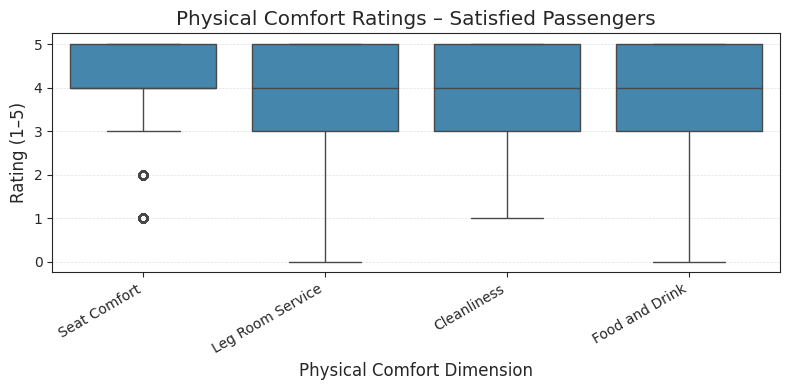

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=physical_comfort_melted[
        physical_comfort_melted[satisfaction_col] == 'Satisfied'
    ],
    x='Physical Comfort Dimension',
    y='Rating'
)

plt.title('Physical Comfort Ratings – Satisfied Passengers')
plt.xlabel('Physical Comfort Dimension')
plt.ylabel('Rating (1–5)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Among passengers who reported being satisfied, physical comfort ratings are generally concentrated toward the higher end of the scale across all comfort dimensions. Median ratings for seat comfort, leg room, cleanliness, and food and drink are relatively high, with moderate variability.

While some dispersion remains, the overall distribution suggests that satisfied passengers experience consistently acceptable to positive physical comfort conditions during the flight.


#### 7.6.2 Physical Comfort Ratings – Neutral / Dissatisfied Passengers

This visualization presents the distribution of physical comfort ratings among passengers who reported being neutral or dissatisfied. The chart highlights differences in central tendency and variability across physical comfort dimensions within this group.


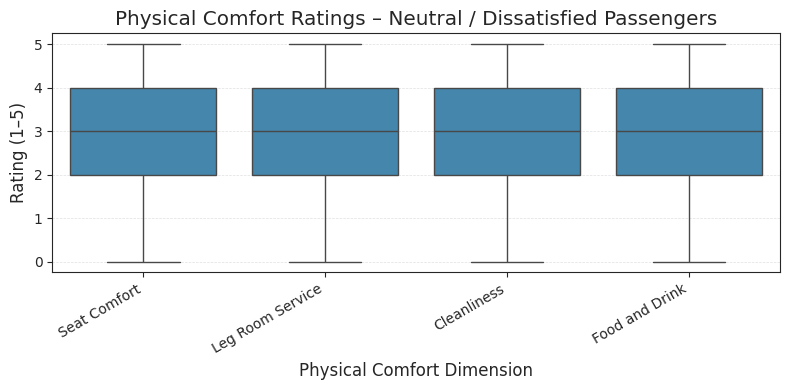

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=physical_comfort_melted[
        physical_comfort_melted[satisfaction_col] == 'Neutral or Dissatisfied'
    ],
    x='Physical Comfort Dimension',
    y='Rating'
)

plt.title('Physical Comfort Ratings – Neutral / Dissatisfied Passengers')
plt.xlabel('Physical Comfort Dimension')
plt.ylabel('Rating (1–5)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In contrast, passengers who reported being neutral or dissatisfied exhibit lower central ratings and wider variability across physical comfort dimensions. Distributions show greater spread toward mid and lower values, indicating less consistent comfort experiences.

This pattern suggests that dissatisfaction is associated not only with reduced physical comfort levels but also with increased inconsistency across multiple in-cabin comfort factors.


#### 7.6.3 Physical Comfort Summary

Comparing distributions across satisfaction groups, physical comfort factors demonstrate a clear association with passenger satisfaction at the exploratory level. Satisfied passengers consistently report higher and more tightly clustered comfort ratings, while neutral or dissatisfied passengers show lower medians and greater variability.

Similar to service execution, dissatisfaction related to physical comfort does not appear to stem from a single dominant factor. Instead, multiple physical comfort dimensions collectively contribute to dissatisfaction, suggesting that overall in-cabin comfort plays an important role in shaping passenger satisfaction outcomes.


### 7.7 Satisfaction vs Digital Experience




This subsection examines how digital experience perceptions differ between passengers who reported being satisfied and those who were neutral or dissatisfied. Digital experience represents technology-enabled touchpoints that support the passenger journey before and during the flight.

The analysis focuses on distributional differences in digital experience ratings across satisfaction groups. All visualizations in this subsection are exploratory and use boxplots to assess central tendency and variability across digital experience dimensions within each group.

In [ ]:
digital_experience_cols = [
    'In-flight Wifi Service',
    'Ease of Online Booking',
    'In-flight Entertainment'
]

df[[satisfaction_col] + digital_experience_cols].head()


,Satisfaction,In-flight Wifi Service,Ease of Online Booking,In-flight Entertainment
0,Neutral or Dissatisfied,3,3,5
1,Satisfied,2,2,5
2,Satisfied,4,4,3
3,Satisfied,2,2,5
4,Satisfied,3,3,3


In [ ]:
digital_experience_melted = df.melt(
    id_vars=satisfaction_col,
    value_vars=digital_experience_cols,
    var_name='Digital Experience Dimension',
    value_name='Rating'
)
digital_experience_melted

,Satisfaction,Digital Experience Dimension,Rating
0,Neutral or Dissatisfied,In-flight Wifi Service,3
1,Satisfied,In-flight Wifi Service,2
2,Satisfied,In-flight Wifi Service,4
3,Satisfied,In-flight Wifi Service,2
4,Satisfied,In-flight Wifi Service,3
...,...,...,...
388456,Neutral or Dissatisfied,In-flight Entertainment,4
388457,Neutral or Dissatisfied,In-flight Entertainment,2
388458,Neutral or Dissatisfied,In-flight Entertainment,3
388459,Satisfied,In-flight Entertainment,3


####7.7.1 Digital Experience Ratings – Satisfied Passengers

This visualization presents the distribution of digital experience ratings among passengers who reported being satisfied. The chart summarizes perceived performance across key digital experience dimensions, highlighting how ratings are distributed within this group.

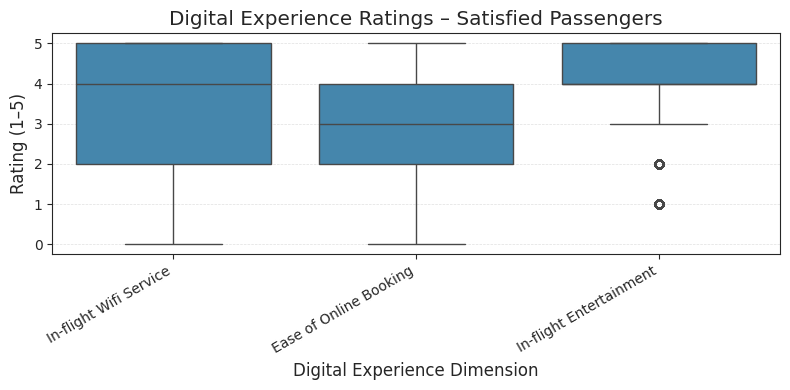

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=digital_experience_melted[
        digital_experience_melted[satisfaction_col] == 'Satisfied'
    ],
    x='Digital Experience Dimension',
    y='Rating'
)

plt.title('Digital Experience Ratings – Satisfied Passengers')
plt.xlabel('Digital Experience Dimension')
plt.ylabel('Rating (1–5)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Among passengers who reported being satisfied, digital experience ratings show relatively high central tendencies across all digital dimensions. In-flight entertainment exhibits the highest median rating with a tighter distribution, indicating more consistently positive perceptions within this group.

In contrast, in-flight WiFi and ease of online booking display wider variability, suggesting that even among satisfied passengers, digital experience quality is perceived less uniformly compared to other service dimensions.


####7.7.2 Digital Experience Ratings – Neutral / Dissatisfied Passengers

This visualization presents the distribution of digital experience ratings among passengers who reported being neutral or dissatisfied. The chart highlights differences in central tendency and variability across digital experience dimensions within this group.

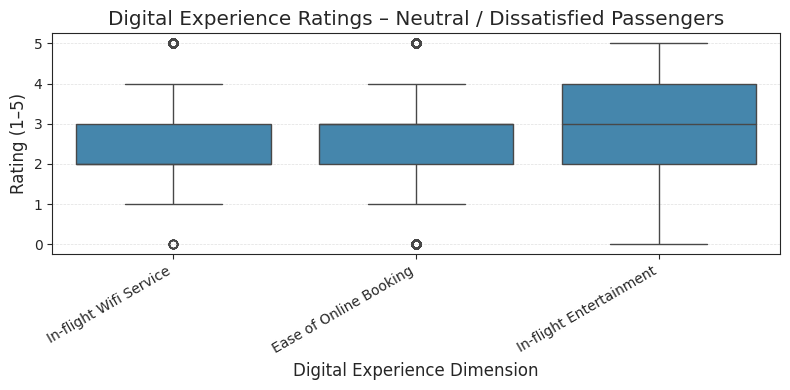

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=digital_experience_melted[
        digital_experience_melted[satisfaction_col] == 'Neutral or Dissatisfied'
    ],
    x='Digital Experience Dimension',
    y='Rating'
)

plt.title('Digital Experience Ratings – Neutral / Dissatisfied Passengers')
plt.xlabel('Digital Experience Dimension')
plt.ylabel('Rating (1–5)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


For passengers who reported being neutral or dissatisfied, digital experience ratings shift toward lower median values with broader distributions across all dimensions. In-flight WiFi and ease of online booking show substantial variability, indicating inconsistent digital performance experiences within this group.

Although in-flight entertainment maintains relatively higher ratings compared to other digital features, overall distributions suggest weaker and less stable digital experiences among neutral or dissatisfied passengers.


#### 7.7.3 Digital Experience Summary

Compared to service execution and physical comfort, digital experience factors demonstrate weaker distributional separation between satisfaction groups. While neutral or dissatisfied passengers generally report lower digital experience ratings, substantial overlap remains across distributions.

At the exploratory level, these patterns suggest that digital experience contributes to passenger dissatisfaction but does not emerge as a dominant or primary driver. Digital touchpoints appear to play a secondary, supporting role in shaping overall passenger satisfaction outcomes.


### 7.8 Cross-Dimensional Exploratory Summary


#### 7.8.1 Consistent Patterns Across Satisfaction Groups  


Across all exploratory dimensions analyzed, a consistent directional pattern emerges between satisfaction groups. Passengers who reported being satisfied generally exhibit higher central tendencies and tighter rating distributions compared to those who were neutral or dissatisfied.

This pattern is observed across operational reliability, service execution, physical comfort, and digital experience dimensions. In each case, satisfied passengers tend to cluster around higher rating values, while neutral or dissatisfied passengers show lower medians and wider variability, indicating more heterogeneous and unstable experiences.

Importantly, these patterns remain consistent despite differences in measurement scale and service context. Whether the dimension reflects operational performance (e.g., delays), human-delivered services, physical comfort attributes, or digital touchpoints, satisfaction outcomes align directionally with perceived quality levels.

At the exploratory level, this consistency supports the assumption that passenger satisfaction is not driven by isolated factors but reflects a cumulative experience across multiple journey dimensions.


#### 7.8.2 Dimensions with Strongest Separation  


Among the dimensions examined, operational reliability and core service execution exhibit the strongest distributional separation between satisfaction groups.

For operational reliability, both arrival delay and departure delay show clear contrasts between satisfied and neutral or dissatisfied passengers. Neutral or dissatisfied passengers experience noticeably higher delays and greater variability, while satisfied passengers are more tightly clustered around lower delay values. This indicates a strong association between operational performance stability and dissatisfaction outcomes at the exploratory level.

Service execution dimensions, including check-in service, on-board service, and in-flight service, also demonstrate pronounced separation. Satisfied passengers consistently report higher median ratings with narrower distributions, whereas neutral or dissatisfied passengers show lower central tendencies and broader spreads. These patterns suggest that human-led and process-driven service touchpoints play a significant role in differentiating satisfaction outcomes.

Physical comfort dimensions display moderate but still visible separation. While satisfied passengers generally rate seat comfort, leg room, cleanliness, and food and drink higher, the degree of overlap between satisfaction groups is greater compared to operational reliability and service execution.

At the exploratory level, these findings indicate that operational reliability and service execution emerge as the dimensions most strongly associated with passenger dissatisfaction, showing clearer and more consistent separation across satisfaction groups than other dimensions.


#### 7.8.3 Dimensions with Limited Differentiation

In contrast to operational reliability and service execution, digital experience dimensions exhibit more limited distributional differentiation between satisfaction groups.

Across in-flight WiFi service, ease of online booking, and in-flight entertainment, satisfied passengers generally report higher ratings than neutral or dissatisfied passengers. However, the distributions show substantial overlap, with relatively small differences in medians and comparable levels of variability across groups. This indicates weaker separation compared to other examined dimensions.

Physical comfort dimensions also display partial overlap between satisfaction groups. While satisfied passengers tend to rate physical comfort factors more favorably, the distributions suggest that these factors alone do not clearly distinguish between satisfaction outcomes in the same way as operational or service execution dimensions.

At the exploratory level, these patterns suggest that digital experience and, to a lesser extent, physical comfort function as supporting factors rather than primary differentiators of passenger satisfaction. Dissatisfaction appears less likely to be driven by isolated digital or comfort issues and more closely associated with broader operational and service execution challenges.


## Baseline Driver Analysis (Overall)


This section establishes the baseline driver prioritization by comparing
service and operational performance between satisfied and dissatisfied passengers.

The objective is to identify which service and operational factors show the
largest performance gaps and therefore represent the highest improvement
priorities at an overall level.

This baseline will be used as a reference point for subsequent
segment-level analyses.


In [ ]:
# --- Identify Service & Operational Driver Columns ---

driver_cols = [
    'Departure and Arrival Time Convenience',
    'Check-in Service',
    'Online Boarding',
    'Seat Comfort',
    'Leg Room Service',
    'Cleanliness',
    'Food and Drink',
    'In-flight Service',
    'In-flight Wifi Service',
    'In-flight Entertainment',
    'Baggage Handling'
]

# Sanity check: ensure all drivers exist
missing_drivers = [col for col in driver_cols if col not in df.columns]
missing_drivers


[]

In [ ]:
df['Satisfaction'].value_counts()


,count
Satisfaction,
Neutral or Dissatisfied,73225
Satisfied,56262


In [ ]:
# Split satisfaction groups
satisfied_df = df[df['Satisfaction'] == 'Satisfied']
dissatisfied_df = df[df['Satisfaction'] == 'Neutral or Dissatisfied']

# Sanity check
satisfied_df.shape, dissatisfied_df.shape


((56262, 26), (73225, 26))

In [ ]:
satisfied_means = satisfied_df[driver_cols].mean()
dissatisfied_means = dissatisfied_df[driver_cols].mean()

driver_gap = (satisfied_means - dissatisfied_means).sort_values(ascending=False)
driver_gap


,0
Online Boarding,1.366802
In-flight Entertainment,1.072109
Seat Comfort,0.927651
Leg Room Service,0.829881
Cleanliness,0.813283
In-flight Wifi Service,0.759665
Check-in Service,0.605741
Baggage Handling,0.591957
In-flight Service,0.581615
Food and Drink,0.566536


**Key Baseline Insight**

At an overall level, satisfaction differences are most strongly associated with
service experience factors such as online boarding, in-flight entertainment,
and physical comfort.

Operational timing convenience shows a relatively small or inverse gap,
suggesting that schedule convenience alone does not explain overall passenger
dissatisfaction and may interact with passenger context such as travel class
or delay severity.


## Segment-Level Driver Analysis by Travel Class


This section evaluates whether the drivers that differentiate satisfied and
dissatisfied passengers vary by **travel class**.

The same driver gap logic used in the overall baseline is applied
*within each travel class*, allowing comparison of prioritization
between Business and Economy passengers.


In [ ]:
df['Class'].value_counts()

,count
Class,
Business,61990
Economy,58117
Economy Plus,9380


In [ ]:
def compute_driver_gap_by_segment(data, driver_cols):
    """
    Compute driver gap (Satisfied - Dissatisfied) for a given data subset.
    """
    satisfied = data[data['Satisfaction'] == 'Satisfied']
    dissatisfied = data[data['Satisfaction'] == 'Neutral or Dissatisfied']

    # Safety check
    if len(satisfied) == 0 or len(dissatisfied) == 0:
        return None

    satisfied_means = satisfied[driver_cols].mean()
    dissatisfied_means = dissatisfied[driver_cols].mean()

    gap = (satisfied_means - dissatisfied_means).sort_values(ascending=False)

    return gap


In [ ]:
# --- Driver Gap by Class ---

class_segments = {
    'Business': 'Business',
    'Economy': 'Economy',
    'Economy Plus': 'Economy Plus'
}

driver_gap_by_class = {}

for class_name, class_label in class_segments.items():
    segment_df = df[df['Class'] == class_label]

    gap = compute_driver_gap_by_segment(
        segment_df,
        driver_cols
    )

    driver_gap_by_class[class_name] = gap


In [ ]:
driver_gap_by_class['Business']

,0
In-flight Entertainment,1.360778
Online Boarding,1.351422
Leg Room Service,1.135270
Seat Comfort,1.097873
Cleanliness,1.080558
In-flight Service,0.926343
Baggage Handling,0.925598
Check-in Service,0.868223
Food and Drink,0.628769
In-flight Wifi Service,0.538420


In [ ]:
driver_gap_by_class['Economy Plus']

,0
In-flight Wifi Service,1.465124
Online Boarding,1.054361
In-flight Entertainment,1.032506
Food and Drink,0.818795
Cleanliness,0.812340
Seat Comfort,0.723762
Leg Room Service,0.220681
Check-in Service,0.110424
Baggage Handling,-0.077356
In-flight Service,-0.089666


In [ ]:
driver_gap_by_class['Economy']

,0
In-flight Wifi Service,1.472445
Online Boarding,1.064090
In-flight Entertainment,0.644441
Food and Drink,0.502403
Cleanliness,0.473242
Seat Comfort,0.433838
Leg Room Service,0.223203
Check-in Service,0.122008
Baggage Handling,0.030058
In-flight Service,0.024975


In [ ]:
def plot_driver_gap(gap_series, title):
    """
    Plots horizontal bar chart for driver gap values.
    """
    gap_series = gap_series.sort_values()

    plt.figure(figsize=(8, 5))
    plt.barh(gap_series.index, gap_series.values)
    plt.title(title)
    plt.xlabel('Satisfaction Gap (Satisfied − Dissatisfied)')
    plt.tight_layout()
    plt.show()


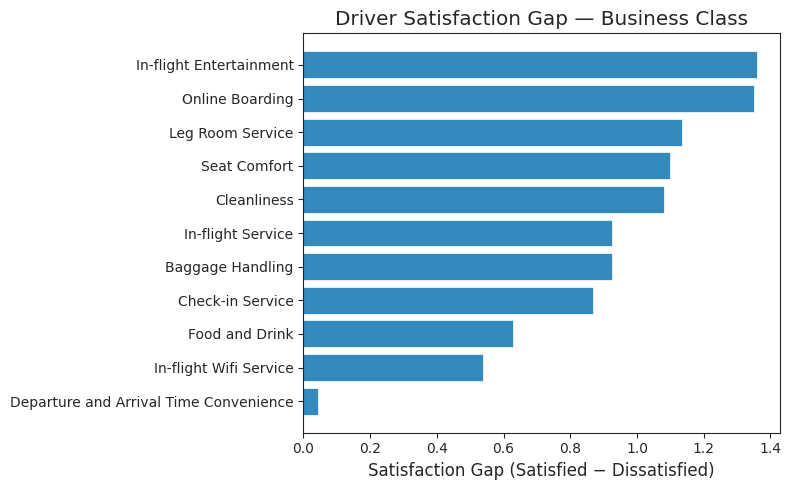

In [ ]:
plot_driver_gap(
    driver_gap_by_class['Business'],
    'Driver Satisfaction Gap — Business Class'
)


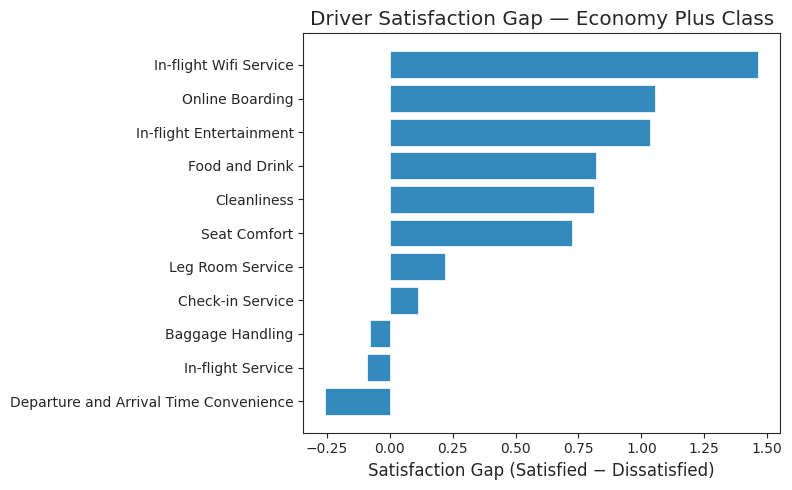

In [ ]:
plot_driver_gap(
    driver_gap_by_class['Economy Plus'],
    'Driver Satisfaction Gap — Economy Plus Class'
)


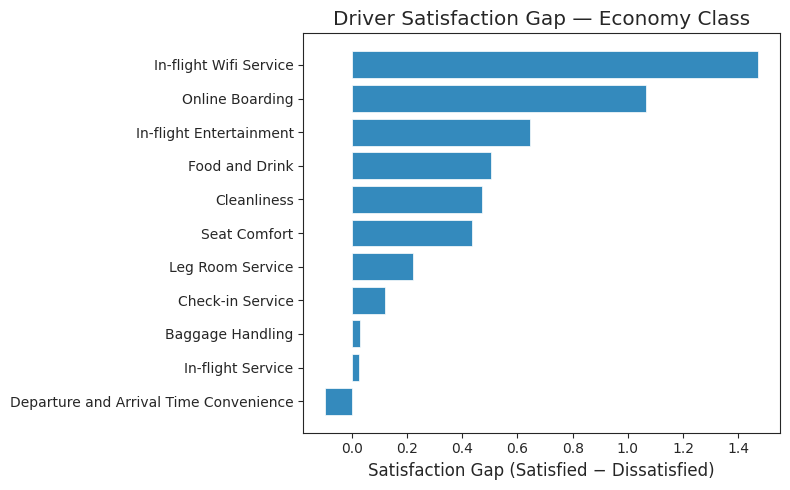

In [ ]:
plot_driver_gap(
    driver_gap_by_class['Economy'],
    'Driver Satisfaction Gap — Economy Class'
)


In [ ]:
# --- Combine Driver Gaps Across Classes ---

driver_gap_df = (
    pd.concat(
        [
            driver_gap_by_class['Business'],
            driver_gap_by_class['Economy Plus'],
            driver_gap_by_class['Economy']
        ],
        axis=1
    )
)

driver_gap_df.columns = ['Business', 'Economy Plus', 'Economy']

driver_gap_df


,Business,Economy Plus,Economy
In-flight Entertainment,1.360778,1.032506,0.644441
Online Boarding,1.351422,1.054361,1.064090
Leg Room Service,1.135270,0.220681,0.223203
Seat Comfort,1.097873,0.723762,0.433838
Cleanliness,1.080558,0.812340,0.473242
In-flight Service,0.926343,-0.089666,0.024975
Baggage Handling,0.925598,-0.077356,0.030058
Check-in Service,0.868223,0.110424,0.122008
Food and Drink,0.628769,0.818795,0.502403
In-flight Wifi Service,0.538420,1.465124,1.472445


In [ ]:
# --- Prepare Driver Gap Data for Tableau ---

driver_gap_long = (
    driver_gap_df
    .reset_index()
    .rename(columns={'index': 'Driver'})
    .melt(
        id_vars='Driver',
        var_name='Class',
        value_name='Driver_Gap'
    )
)

driver_gap_long


,Driver,Class,Driver_Gap
0,In-flight Entertainment,Business,1.360778
1,Online Boarding,Business,1.351422
2,Leg Room Service,Business,1.135270
3,Seat Comfort,Business,1.097873
4,Cleanliness,Business,1.080558
5,In-flight Service,Business,0.926343
6,Baggage Handling,Business,0.925598
7,Check-in Service,Business,0.868223
8,Food and Drink,Business,0.628769
9,In-flight Wifi Service,Business,0.538420


### Segment-Level Driver Gap Comparison (By Travel Class)

The table above compares satisfaction driver gaps (Satisfied − Dissatisfied)
across three passenger segments: Business, Economy Plus, and Economy.

Key observations:
- Business Class passengers show the largest gaps in premium experience drivers
  such as seat comfort, leg room, and in-flight entertainment, indicating higher
  sensitivity to comfort and onboard service quality.
- Economy Plus passengers exhibit mixed priorities, bridging comfort-related
  drivers and digital or service execution factors, suggesting expectation
  misalignment within this transitional segment.
- Economy Class passengers show comparatively smaller gaps across comfort
  dimensions, with relatively higher sensitivity to digital experience and
  boarding-related services.

These differences indicate that improvement priorities are not uniform across
passenger classes and should be tailored based on segment-specific sensitivity
to service and operational drivers.


##Segment-Level Driver Gap Analysis: Delay Severity

In [ ]:
df['Delay_Severity']


,Delay_Severity
0,Minor Delay
1,Major Delay
2,On Time
3,On Time
4,Minor Delay
...,...
129875,Minor Delay
129876,On Time
129877,Minor Delay
129878,Minor Delay


In [ ]:
def compute_driver_gap_by_segment(data, driver_cols):
    satisfied = data[data['Satisfaction'] == 'Satisfied']
    dissatisfied = data[data['Satisfaction'] == 'Neutral or Dissatisfied']

    if len(satisfied) == 0 or len(dissatisfied) == 0:
        return None

    satisfied_means = satisfied[driver_cols].mean()
    dissatisfied_means = dissatisfied[driver_cols].mean()

    gap = (satisfied_means - dissatisfied_means).sort_values(ascending=False)
    return gap


In [ ]:
on_time_df = df[df['Delay_Severity'] == 'On Time']

on_time_driver_gap = compute_driver_gap_by_segment(
    on_time_df,
    driver_cols
)

on_time_driver_gap


,0
Online Boarding,1.343377
In-flight Entertainment,1.039634
Seat Comfort,0.872191
Leg Room Service,0.812530
Cleanliness,0.766936
In-flight Wifi Service,0.760224
Baggage Handling,0.555344
In-flight Service,0.534901
Check-in Service,0.531030
Food and Drink,0.507312


In [ ]:
minor_delay_df = df[df['Delay_Severity'] == 'Minor Delay']

minor_delay_driver_gap = compute_driver_gap_by_segment(
    minor_delay_df,
    driver_cols
)

minor_delay_driver_gap


,0
Online Boarding,1.399281
In-flight Entertainment,1.124501
Seat Comfort,0.991411
Leg Room Service,0.886105
Cleanliness,0.852182
In-flight Wifi Service,0.744947
Check-in Service,0.667207
Baggage Handling,0.633725
In-flight Service,0.615741
Food and Drink,0.570771


In [ ]:
major_delay_df = df[df['Delay_Severity'] == 'Major Delay']

major_delay_driver_gap = compute_driver_gap_by_segment(
    major_delay_df,
    driver_cols
)

major_delay_driver_gap


,0
Online Boarding,1.409428
In-flight Entertainment,1.091859
Seat Comfort,1.027280
Cleanliness,0.926283
Leg Room Service,0.803241
Food and Drink,0.793301
In-flight Wifi Service,0.776966
Check-in Service,0.775252
In-flight Service,0.667148
Baggage Handling,0.650465


In [ ]:
delay_driver_gap_df = pd.concat(
    [
        on_time_driver_gap,
        minor_delay_driver_gap,
        major_delay_driver_gap
    ],
    axis=1
)

delay_driver_gap_df.columns = ['On Time', 'Minor Delay', 'Major Delay']

delay_driver_gap_df


,On Time,Minor Delay,Major Delay
Online Boarding,1.343377,1.399281,1.409428
In-flight Entertainment,1.039634,1.124501,1.091859
Seat Comfort,0.872191,0.991411,1.027280
Leg Room Service,0.812530,0.886105,0.803241
Cleanliness,0.766936,0.852182,0.926283
In-flight Wifi Service,0.760224,0.744947,0.776966
Baggage Handling,0.555344,0.633725,0.650465
In-flight Service,0.534901,0.615741,0.667148
Check-in Service,0.531030,0.667207,0.775252
Food and Drink,0.507312,0.570771,0.793301


### Segment-Level Driver Gap: Customer Type


In [ ]:
df['Customer Type'].value_counts()


,count
Customer Type,
Returning,105773
First-time,23714


In [ ]:
# --- Driver Gap: Customer Type ---

first_time_df = df[df['Customer Type'] == 'First-time']
returning_df = df[df['Customer Type'] == 'Returning']

first_time_driver_gap = compute_driver_gap_by_segment(
    first_time_df,
    driver_cols
)

returning_driver_gap = compute_driver_gap_by_segment(
    returning_df,
    driver_cols
)


In [ ]:
customer_type_driver_gap_df = pd.concat(
    [
        first_time_driver_gap,
        returning_driver_gap
    ],
    axis=1
)

customer_type_driver_gap_df.columns = [
    'First-time Customer',
    'Returning Customer'
]

customer_type_driver_gap_df


,First-time Customer,Returning Customer
In-flight Wifi Service,1.329882,0.694371
Online Boarding,1.201844,1.335158
Check-in Service,0.671082,0.602383
Baggage Handling,0.539404,0.638583
In-flight Service,0.529658,0.626902
Departure and Arrival Time Convenience,0.441482,-0.417368
Leg Room Service,0.217717,0.936848
Food and Drink,0.094454,0.633131
In-flight Entertainment,0.071392,1.216686
Cleanliness,0.033537,0.926545


##Segment-Level Driver Gap Analysis: Travel Type

In [ ]:
df['Type of Travel'].value_counts()


,count
Type of Travel,
Business,89445
Personal,40042


In [ ]:
business_travel_df = df[df['Type of Travel'] == 'Business']
personal_travel_df = df[df['Type of Travel'] == 'Personal']


In [ ]:
# Compute driver gaps
business_travel_driver_gap = compute_driver_gap_by_segment(
    business_travel_df,
    driver_cols
)

personal_travel_driver_gap = compute_driver_gap_by_segment(
    personal_travel_df,
    driver_cols
)

business_travel_driver_gap, personal_travel_driver_gap


(Online Boarding                           1.465906
 In-flight Entertainment                   1.302362
 Seat Comfort                              1.131416
 Cleanliness                               1.045320
 Leg Room Service                          0.936149
 Check-in Service                          0.911907
 Baggage Handling                          0.814913
 In-flight Service                         0.812938
 In-flight Wifi Service                    0.722382
 Food and Drink                            0.700361
 Departure and Arrival Time Convenience    0.273721
 dtype: float64,
 In-flight Wifi Service                    1.212078
 Online Boarding                           0.795479
 Leg Room Service                          0.207008
 Food and Drink                            0.044985
 Seat Comfort                              0.019462
 Check-in Service                          0.015463
 Departure and Arrival Time Convenience    0.014123
 In-flight Service                         0.01

In [ ]:
# Combine into comparison table
travel_type_driver_gap_df = pd.concat(
    [
        business_travel_driver_gap,
        personal_travel_driver_gap
    ],
    axis=1
)

travel_type_driver_gap_df.columns = [
    'Business Travel',
    'Personal Travel'
]

travel_type_driver_gap_df


,Business Travel,Personal Travel
Online Boarding,1.465906,0.795479
In-flight Entertainment,1.302362,-0.021464
Seat Comfort,1.131416,0.019462
Cleanliness,1.045320,-0.010931
Leg Room Service,0.936149,0.207008
Check-in Service,0.911907,0.015463
Baggage Handling,0.814913,0.000041
In-flight Service,0.812938,0.011020
In-flight Wifi Service,0.722382,1.212078
Food and Drink,0.700361,0.044985


##Segment-Level Driver Gap Analysis: Age Band

In [ ]:
df['Age_Band'].value_counts()


,count
Age_Band,
Adult,40953
Older Adult,38127
Young Adult,28428
Senior,12168
Teen,9811


In [ ]:
age_band_driver_gaps = {}

for band in df['Age_Band'].unique():
    band_df = df[df['Age_Band'] == band]

    gap = compute_driver_gap_by_segment(
        band_df,
        driver_cols
    )

    age_band_driver_gaps[band] = gap


In [ ]:
age_band_driver_gap_df = pd.concat(
    age_band_driver_gaps,
    axis=1
)

age_band_driver_gap_df


,Older Adult,Adult,Senior,Young Adult,Teen
Leg Room Service,1.308874,0.817448,1.114339,0.133883,0.044715
In-flight Entertainment,1.260298,1.184606,1.028627,0.678436,0.490414
Online Boarding,1.184243,1.446109,0.828599,1.409631,1.339861
Seat Comfort,0.952898,1.042021,0.556204,0.678505,0.459693
Baggage Handling,0.941826,0.562326,0.710747,0.317345,0.135013
In-flight Service,0.933755,0.542111,0.690543,0.324539,0.122370
Cleanliness,0.889797,0.905901,0.582940,0.672985,0.492297
Check-in Service,0.756378,0.592049,0.427786,0.547101,0.310185
In-flight Wifi Service,0.673965,0.737368,0.788146,0.920920,1.072791
Food and Drink,0.452726,0.648706,0.342859,0.709610,0.514074


## 8.EDA Hypothesis Assessment

This section evaluates the predefined hypotheses using evidence derived from the exploratory data analysis presented in Section 7. All assessments are conducted at the exploratory level and focus on observed distributional patterns rather than causal inference or statistical testing.

Each hypothesis is reviewed using a consistent structure, including the EDA evidence referenced, observed patterns across satisfaction groups, and a final assessment indicating whether the hypothesis is supported at the exploratory level.


### 8.1Hypothesis 1 (H1): Operational Reliability vs Digital Experience


####**Hypothesis Statement**  
Operational reliability and ground operation factors have a stronger association with passenger dissatisfaction than digital experience factors.

**EDA Evidence Used**  
This hypothesis is evaluated using distributional comparisons from Section 7.4 (Operational Reliability) and Section 7.7 (Digital Experience), focusing on differences between satisfied and neutral or dissatisfied passengers.

**Observed EDA Patterns**  
Operational reliability metrics, specifically arrival delay and departure delay, show clear and consistent distributional separation between satisfaction groups. Neutral or dissatisfied passengers experience higher delays and greater variability, while satisfied passengers are more tightly clustered around lower delay values.

In contrast, digital experience dimensions such as in-flight WiFi, ease of online booking, and in-flight entertainment exhibit weaker separation. Although neutral or dissatisfied passengers generally report lower digital experience ratings, substantial overlap remains between satisfaction groups, and differences in central tendency are less pronounced.

**EDA-Level Assessment**  
Supported.

### 8.2Hypothesis 2 (H2): Service Execution & Physical Comfort vs Digital Experience


#### **Hypothesis Statement**  
Physical comfort and service execution factors contribute more to overall passenger satisfaction than individual digital features.

**EDA Evidence Used**  
This hypothesis is assessed using distributional comparisons from Section 7.5 (Service Execution), Section 7.6 (Physical Comfort), and Section 7.7 (Digital Experience), focusing on rating differences across satisfaction groups.

**Observed EDA Patterns**  
Service execution dimensions, including check-in service, on-board service, and in-flight service, display strong distributional separation between satisfaction groups. Satisfied passengers consistently report higher median ratings with narrower distributions, while neutral or dissatisfied passengers show lower central tendencies and greater variability.

Physical comfort dimensions, such as seat comfort, leg room, cleanliness, and food and drink, also demonstrate visible separation between satisfaction groups, though with greater overlap compared to service execution. Nonetheless, satisfied passengers tend to rate physical comfort factors more favorably overall.

In contrast, digital experience dimensions exhibit weaker separation. While neutral or dissatisfied passengers generally report lower digital experience ratings, substantial overlap remains across satisfaction groups, indicating a less pronounced association with overall satisfaction outcomes.

**EDA-Level Assessment**  
Supported.

### 8.3 Hypothesis 3 (H3): Concentration of Dissatisfaction Drivers


#### **Hypothesis Statement**  
A small subset of service and operational factors explains a disproportionate share of dissatisfaction outcomes.

**EDA Evidence Used**  
This hypothesis is evaluated using cross-dimensional exploratory findings from Section 7.4 through Section 7.7, encompassing operational reliability, service execution, physical comfort, and digital experience dimensions.

**Observed EDA Patterns**  
Across all examined dimensions, neutral or dissatisfied passengers exhibit lower ratings or poorer performance relative to satisfied passengers. However, dissatisfaction signals are observed across multiple factors rather than being concentrated within a small number of variables.

Operational reliability shows strong dissatisfaction signals, but similar patterns of lower central tendencies and increased variability are also present in service execution and physical comfort dimensions. Digital experience, while weaker, still contributes to dissatisfaction signals with overlapping distributions.

No single factor or narrowly defined subset consistently dominates dissatisfaction outcomes. Instead, dissatisfaction appears to be distributed across several service and operational dimensions, reflecting a broad-based pattern rather than a highly concentrated one.

**EDA-Level Assessment**  
Not Supported.

## Random Check


In [ ]:
df.isna().sum()


,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,0
Departure and Arrival Time Convenience,0


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.shape


(129487, 26)

In [ ]:
df['Arrival Delay'].describe()


,Arrival Delay
count,129487.000000
mean,15.091129
std,38.465650
min,0.000000
25%,0.000000
50%,0.000000
75%,13.000000
max,1584.000000


In [ ]:
df['Departure Delay'].describe()


,Departure Delay
count,129487.000000
mean,14.643385
std,37.932867
min,0.000000
25%,0.000000
50%,0.000000
75%,12.000000
max,1592.000000


In [ ]:
df['Satisfaction'].value_counts()



,count
Satisfaction,
Neutral or Dissatisfied,73225
Satisfied,56262


In [ ]:
df['Gender'].value_counts()


,count
Gender,
Female,65703
Male,63784


In [ ]:
df['Customer Type'].value_counts()


,count
Customer Type,
Returning,105773
First-time,23714


In [ ]:
df['Type of Travel'].value_counts()


,count
Type of Travel,
Business,89445
Personal,40042


In [ ]:
df['Class'].value_counts()

,count
Class,
Business,61990
Economy,58117
Economy Plus,9380


In [ ]:
df.dtypes


,0
ID,object
Gender,object
Age,int64
Customer Type,object
Type of Travel,object
Class,object
Flight Distance,int64
Departure Delay,float64
Arrival Delay,float64
Departure and Arrival Time Convenience,int64


In [ ]:
df.to_csv('airline_passenger_satisfaction_clean.csv', index=False)


In [ ]:
df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction,Age_Band,Delay_Severity
0,1,Male,48,First-time,Business,Business,821,2.0,5.0,3,...,2,5,5,5,3,5,5,Neutral or Dissatisfied,Older Adult,Minor Delay
1,2,Female,35,Returning,Business,Business,821,26.0,39.0,2,...,5,5,3,5,2,5,5,Satisfied,Adult,Major Delay
2,3,Male,41,Returning,Business,Business,853,0.0,0.0,4,...,3,5,5,3,4,3,3,Satisfied,Adult,On Time
3,4,Male,50,Returning,Business,Business,1905,0.0,0.0,2,...,5,4,4,5,2,5,5,Satisfied,Older Adult,On Time
4,5,Female,49,Returning,Business,Business,3470,0.0,1.0,3,...,4,5,4,3,3,3,3,Satisfied,Older Adult,Minor Delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2.0,3.0,4,...,4,4,4,5,4,4,4,Neutral or Dissatisfied,Young Adult,Minor Delay
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0.0,0.0,5,...,5,2,2,4,3,2,5,Neutral or Dissatisfied,Adult,On Time
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6.0,14.0,5,...,4,3,3,4,2,3,5,Neutral or Dissatisfied,Adult,Minor Delay
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31.0,22.0,4,...,5,3,3,4,5,3,5,Satisfied,Older Adult,Minor Delay


##Make Gap df

In [ ]:
def compute_driver_gap_long(data, driver_cols, segment_value, segment_type):
    """
    Compute driver gap (Satisfied - Dissatisfied) in LONG format.
    """

    satisfied = data[data['Satisfaction'] == 'Satisfied']
    dissatisfied = data[data['Satisfaction'] == 'Neutral or Dissatisfied']

    # Safety check
    if len(satisfied) == 0 or len(dissatisfied) == 0:
        return None

    sat_mean = satisfied[driver_cols].mean()
    dis_mean = dissatisfied[driver_cols].mean()

    gap = sat_mean - dis_mean

    gap_df = gap.reset_index()
    gap_df.columns = ['Driver', 'Driver_Gap']
    gap_df['Segment'] = segment_value
    gap_df['Segment_Type'] = segment_type

    return gap_df


In [ ]:
gap_dfs = []


In [ ]:
for cls in df['Class'].unique():
    cls_df = df[df['Class'] == cls]

    gap_df = compute_driver_gap_long(
        cls_df,
        driver_cols,
        segment_value=cls,
        segment_type='Class'
    )

    if gap_df is not None:
        gap_dfs.append(gap_df)


In [ ]:
for cust in df['Customer Type'].unique():
    cust_df = df[df['Customer Type'] == cust]

    gap_df = compute_driver_gap_long(
        cust_df,
        driver_cols,
        segment_value=cust,
        segment_type='Customer Type'
    )

    if gap_df is not None:
        gap_dfs.append(gap_df)


In [ ]:
for delay in df['Delay_Severity'].unique():
    delay_df = df[df['Delay_Severity'] == delay]

    gap_df = compute_driver_gap_long(
        delay_df,
        driver_cols,
        segment_value=delay,
        segment_type='Delay Severity'
    )

    if gap_df is not None:
        gap_dfs.append(gap_df)


In [ ]:
for band in df['Age_Band'].unique():
    band_df = df[df['Age_Band'] == band]

    gap_df = compute_driver_gap_long(
        band_df,
        driver_cols,
        segment_value=band,
        segment_type='Age Band'
    )

    if gap_df is not None:
        gap_dfs.append(gap_df)


In [ ]:
driver_gap_long_df = pd.concat(gap_dfs, ignore_index=True)
driver_gap_long_df


,Driver,Driver_Gap,Segment,Segment_Type
0,Departure and Arrival Time Convenience,0.045130,Business,Class
1,Check-in Service,0.868223,Business,Class
2,Online Boarding,1.351422,Business,Class
3,Seat Comfort,1.097873,Business,Class
4,Leg Room Service,1.135270,Business,Class
...,...,...,...,...
138,Food and Drink,0.514074,Teen,Age Band
139,In-flight Service,0.122370,Teen,Age Band
140,In-flight Wifi Service,1.072791,Teen,Age Band
141,In-flight Entertainment,0.490414,Teen,Age Band


In [ ]:
driver_gap_long_df.info()
driver_gap_long_df['Segment_Type'].value_counts()
driver_gap_long_df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Driver        143 non-null    object 
 1   Driver_Gap    143 non-null    float64
 2   Segment       143 non-null    object 
 3   Segment_Type  143 non-null    object 
dtypes: float64(1), object(3)
memory usage: 4.6+ KB


,0
Driver,0
Driver_Gap,0
Segment,0
Segment_Type,0


In [ ]:
driver_gap_long_df.to_csv(
    'driver_gap_long_tableau_ready.csv',
    index=False
)


In [ ]:
df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction,Age_Band,Delay_Severity
0,1,Male,48,First-time,Business,Business,821,2.0,5.0,3,...,2,5,5,5,3,5,5,Neutral or Dissatisfied,Older Adult,Minor Delay
1,2,Female,35,Returning,Business,Business,821,26.0,39.0,2,...,5,5,3,5,2,5,5,Satisfied,Adult,Major Delay
2,3,Male,41,Returning,Business,Business,853,0.0,0.0,4,...,3,5,5,3,4,3,3,Satisfied,Adult,On Time
3,4,Male,50,Returning,Business,Business,1905,0.0,0.0,2,...,5,4,4,5,2,5,5,Satisfied,Older Adult,On Time
4,5,Female,49,Returning,Business,Business,3470,0.0,1.0,3,...,4,5,4,3,3,3,3,Satisfied,Older Adult,Minor Delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2.0,3.0,4,...,4,4,4,5,4,4,4,Neutral or Dissatisfied,Young Adult,Minor Delay
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0.0,0.0,5,...,5,2,2,4,3,2,5,Neutral or Dissatisfied,Adult,On Time
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6.0,14.0,5,...,4,3,3,4,2,3,5,Neutral or Dissatisfied,Adult,Minor Delay
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31.0,22.0,4,...,5,3,3,4,5,3,5,Satisfied,Older Adult,Minor Delay


In [ ]:
driver_gap_long_df

,Driver,Driver_Gap,Segment,Segment_Type
0,Departure and Arrival Time Convenience,0.045130,Business,Class
1,Check-in Service,0.868223,Business,Class
2,Online Boarding,1.351422,Business,Class
3,Seat Comfort,1.097873,Business,Class
4,Leg Room Service,1.135270,Business,Class
...,...,...,...,...
138,Food and Drink,0.514074,Teen,Age Band
139,In-flight Service,0.122370,Teen,Age Band
140,In-flight Wifi Service,1.072791,Teen,Age Band
141,In-flight Entertainment,0.490414,Teen,Age Band


In [ ]:
df.shape



(129487, 26)

In [ ]:
driver_gap_long_df.shape

(143, 4)

In [ ]:
df.to_csv(
    "airline_passenger_satisfaction_clean.csv",
    index=False
)


In [ ]:
driver_gap_long_df.to_csv(
    "driver_gap_long_tableau_ready.csv",
    index=False
)


#IDK MORE EDA


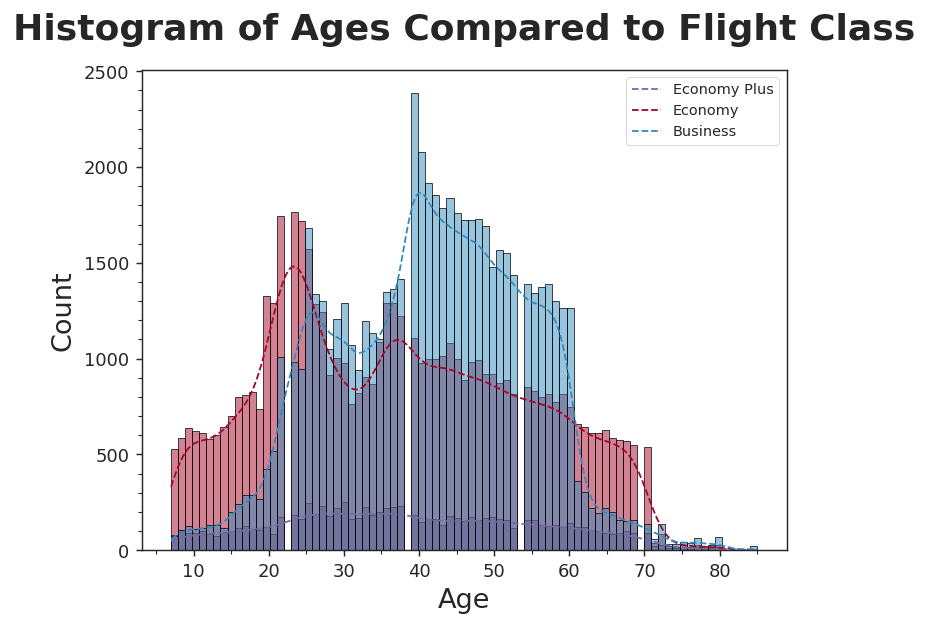

In [ ]:
plt.style.use('bmh')
sns.set_style('ticks')

fig, ax = plt.subplots()

fig.figsize=(3,2)
fig.dpi=130
ax.minorticks_on()
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.yaxis.set_minor_locator(MultipleLocator(100))


plt.title('Histogram of Ages Compared to Flight Class',size=20,fontweight='bold',y=1.04)

sns.histplot(x='Age',data=df,color=['#605E5E'],edgecolor='black',hue='Class',kde=True,line_kws={'lw': 1,'linestyle':'--'})


plt.xlabel('Age',size=15)
plt.ylabel('Count',size=15)

plt.legend(['Economy Plus','Economy'  ,'Business'],fontsize='8')

plt.show()